<a href="https://colab.research.google.com/github/njwbilll/-Tugas-3_Practical-Linear-Algebra--O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/02_Vectors%2CPart_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Vectors, Part 1

**Referensi:** Practical Linear Algebra for Data Science -- Mike X Cohen (O'Reilly, 2022)

---

## Ringkasan Chapter

Vektor adalah fondasi dari seluruh aljabar linear dan semua yang dibangun di atasnya.
Chapter ini membahas semua hal tentang vektor: apa itu, bagaimana menginterpretasikannya,
cara membuat dan memanipulasinya di Python, serta operasi-operasi penting yang bekerja padanya.

**Topik yang dibahas:**
- Membuat dan memvisualisasikan vektor di NumPy
- Geometri vektor
- Operasi vektor: penjumlahan, perkalian skalar, transpose
- Broadcasting di Python
- Magnitude vektor dan unit vector
- Dot product (perkalian dalam)
- Hadamard multiplication dan outer product
- Dekomposisi vektor ortogonal

## 2.0 Import Library"

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

np.random.seed(42)
print("Library berhasil diimport.")
print(f"NumPy version: {np.__version__}")

Library berhasil diimport.
NumPy version: 2.0.2


## 2.1 Membuat dan Memvisualisasikan Vektor di NumPy

### Definisi Vektor

Dalam aljabar linear, **vektor** adalah daftar angka yang terurut.

Dua karakteristik penting vektor:

**Dimensionalitas (Dimensionality)**
Jumlah elemen dalam vektor. Vektor dengan N elemen disebut anggota dari ruang
real N-dimensi, ditulis sebagai R^N. Misalnya, vektor dengan 3 elemen adalah
anggota R^3.

**Orientasi (Orientation)**
Apakah vektor berada dalam orientasi kolom (berdiri) atau orientasi baris (berbaring).

### Terminologi: Matematika vs Python

Perhatikan perbedaan penting antara terminologi matematika dan Python:

| Istilah | Matematika | Python |
|---------|-----------|--------|
| Dimensi | Jumlah elemen dalam vektor | Jumlah dimensi geometri array |
| Panjang (length) | Jarak geometri (magnitude) | `len()` = jumlah elemen |

Vektor dalam Python bisa direpresentasikan dalam empat cara:
1. **List Python**: mudah dibuat, tapi tidak mendukung operasi aljabar linear
2. **1D array (orientationless)**: array NumPy tanpa orientasi tertentu
3. **Row vector**: array 2D berukuran (1, N)
4. **Column vector**: array 2D berukuran (N, 1)

In [2]:
# Empat cara merepresentasikan vektor di Python
asList  = [1, 2, 3]                      # Python list
asArray = np.array([1, 2, 3])            # 1D array (orientationless)
rowVec  = np.array([[1, 2, 3]])          # row vector: shape (1, 3)
colVec  = np.array([[1], [2], [3]])      # column vector: shape (3, 1)

print("=== Empat Representasi Vektor di Python ===")
print()
print(f"asList  : {asList}  -->  type: {type(asList)}")
print(f"asArray : {asArray}  -->  shape: {asArray.shape}")
print(f"rowVec  :\\n{rowVec}  -->  shape: {rowVec.shape}")
print(f"colVec  :\\n{colVec}  -->  shape: {colVec.shape}")
print()
print("Perbedaan kritis:")
print(f"  asArray shape: {asArray.shape}   (1D, tidak punya orientasi)")
print(f"  rowVec  shape: {rowVec.shape}  (2D, orientasi baris)")
print(f"  colVec  shape: {colVec.shape}  (2D, orientasi kolom)")

=== Empat Representasi Vektor di Python ===

asList  : [1, 2, 3]  -->  type: <class 'list'>
asArray : [1 2 3]  -->  shape: (3,)
rowVec  :\n[[1 2 3]]  -->  shape: (1, 3)
colVec  :\n[[1]
 [2]
 [3]]  -->  shape: (3, 1)

Perbedaan kritis:
  asArray shape: (3,)   (1D, tidak punya orientasi)
  rowVec  shape: (1, 3)  (2D, orientasi baris)
  colVec  shape: (3, 1)  (2D, orientasi kolom)


In [3]:
# Membuat vektor dengan berbagai cara lain
v_zeros  = np.zeros(5)           # vektor nol dimensi 5
v_ones   = np.ones(4)            # vektor satu dimensi 4
v_range  = np.arange(1, 8)       # [1, 2, 3, 4, 5, 6, 7]
v_linspace = np.linspace(0, 1, 6) # 6 angka dari 0 ke 1
v_random = np.random.randn(4)    # 4 angka acak distribusi normal

print("=== Cara Membuat Vektor ===")
print(f"zeros(5)         : {v_zeros}")
print(f"ones(4)          : {v_ones}")
print(f"arange(1,8)      : {v_range}")
print(f"linspace(0,1,6)  : {v_linspace.round(3)}")
print(f"randn(4)         : {v_random.round(3)}")

=== Cara Membuat Vektor ===
zeros(5)         : [0. 0. 0. 0. 0.]
ones(4)          : [1. 1. 1. 1.]
arange(1,8)      : [1 2 3 4 5 6 7]
linspace(0,1,6)  : [0.  0.2 0.4 0.6 0.8 1. ]
randn(4)         : [ 0.497 -0.138  0.648  1.523]


## 2.2 Geometri Vektor

### Dua Interpretasi Vektor

**Interpretasi Aljabar (Algebraic)**
Vektor adalah daftar angka terurut. Berguna untuk menyimpan data
(misalnya: data penjualan harian).

**Interpretasi Geometri (Geometric)**
Vektor adalah garis lurus dengan panjang (magnitude) dan arah (angle) tertentu.
- **Tail (ekor)**: titik awal vektor
- **Head (kepala)**: titik akhir vektor, biasanya ditandai dengan panah

### Posisi Standar (Standard Position)

Sebuah vektor dalam posisi standar memiliki tail di titik asal (0, 0)
dan head di koordinat geometris yang sesuai dengan elemen vektor.

Kedua interpretasi ini adalah dua sisi dari koin yang sama.
Interpretasi geometri berguna untuk fisika dan engineering,
sedangkan interpretasi aljabar berguna untuk data science.

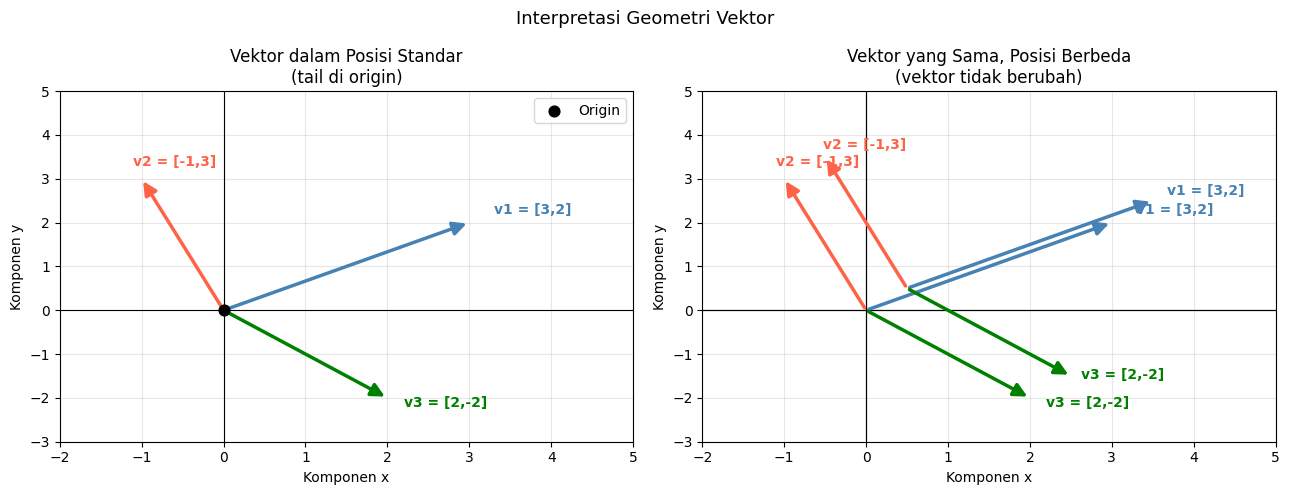

Catatan: vektor yang sama bisa digambar dari posisi manapun.
Identitasnya (arah dan panjang) tetap sama.


In [4]:
# Visualisasi geometri vektor dalam 2D
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Vektor-vektor contoh
vectors_2d = [
    ([3, 2],  "steelblue", "v1 = [3,2]"),
    ([-1, 3], "tomato",    "v2 = [-1,3]"),
    ([2, -2], "green",     "v3 = [2,-2]"),
]

for ax_idx, ax in enumerate(axes):
    for vec, color, label in vectors_2d:
        # Gambar vektor dari asal (0,0)
        ax.annotate("", xy=(vec[0], vec[1]), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=color,
                                    lw=2.5, mutation_scale=20))
        ax.text(vec[0]*1.1, vec[1]*1.1, label, color=color, fontsize=10, fontweight="bold")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-2, 5)
    ax.set_ylim(-3, 5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Komponen x")
    ax.set_ylabel("Komponen y")

axes[0].set_title("Vektor dalam Posisi Standar\n(tail di origin)")
axes[0].scatter([0], [0], color="black", s=60, zorder=5, label="Origin")
axes[0].legend()

# Panel kanan: vektor yang sama tapi ditampilkan dari posisi berbeda
for vec, color, label in vectors_2d:
    start = [0.5, 0.5]  # tail bukan di origin
    end = [start[0] + vec[0], start[1] + vec[1]]
    axes[1].annotate("", xy=end, xytext=start,
                     arrowprops=dict(arrowstyle="-|>", color=color,
                                     lw=2.5, mutation_scale=20))
    axes[1].text(end[0]*1.05, end[1]*1.05, label, color=color, fontsize=10, fontweight="bold")

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlim(-2, 5)
axes[1].set_ylim(-3, 5)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Komponen x")
axes[1].set_ylabel("Komponen y")
axes[1].set_title("Vektor yang Sama, Posisi Berbeda\n(vektor tidak berubah)")

plt.suptitle("Interpretasi Geometri Vektor", fontsize=13)
plt.tight_layout()
plt.show()

print("Catatan: vektor yang sama bisa digambar dari posisi manapun.")
print("Identitasnya (arah dan panjang) tetap sama.")

## 2.3 Operasi pada Vektor

Vektor adalah seperti kata benda, sedangkan operasi adalah kata kerja
yang menghidupkan karakter-karakter tersebut.

### 2.3.1 Penjumlahan Dua Vektor

Untuk menjumlahkan dua vektor, cukup jumlahkan elemen-elemen yang bersesuaian.

Syarat: dua vektor hanya bisa dijumlahkan jika memiliki dimensionalitas
yang sama. Tidak bisa menjumlahkan vektor di R^3 dengan vektor di R^5.

Rumus penjumlahan:
    (a + b)_i = a_i + b_i     untuk setiap i

In [5]:
# Penjumlahan dan pengurangan vektor
v = np.array([4, 5, 6])
w = np.array([10, 20, 30])

v_plus_w  = v + w
v_minus_w = v - w

print("=== Penjumlahan dan Pengurangan Vektor ===")
print(f"v         : {v}")
print(f"w         : {w}")
print(f"v + w     : {v_plus_w}")
print(f"v - w     : {v_minus_w}")
print()

# Verifikasi elemen demi elemen
print("Verifikasi elemen demi elemen (penjumlahan):")
for i in range(len(v)):
    print(f"  Elemen {i}: {v[i]} + {w[i]} = {v[i] + w[i]}")
print()

# Error jika dimensi berbeda
u = np.array([0, 3, 6, 9])  # dimensi 4, berbeda dengan v (dimensi 3)
try:
    result = u + v
except ValueError as e:
    print(f"Error saat menjumlahkan dimensi berbeda: {e}")

=== Penjumlahan dan Pengurangan Vektor ===
v         : [4 5 6]
w         : [10 20 30]
v + w     : [14 25 36]
v - w     : [ -6 -15 -24]

Verifikasi elemen demi elemen (penjumlahan):
  Elemen 0: 4 + 10 = 14
  Elemen 1: 5 + 20 = 25
  Elemen 2: 6 + 30 = 36

Error saat menjumlahkan dimensi berbeda: operands could not be broadcast together with shapes (4,) (3,) 


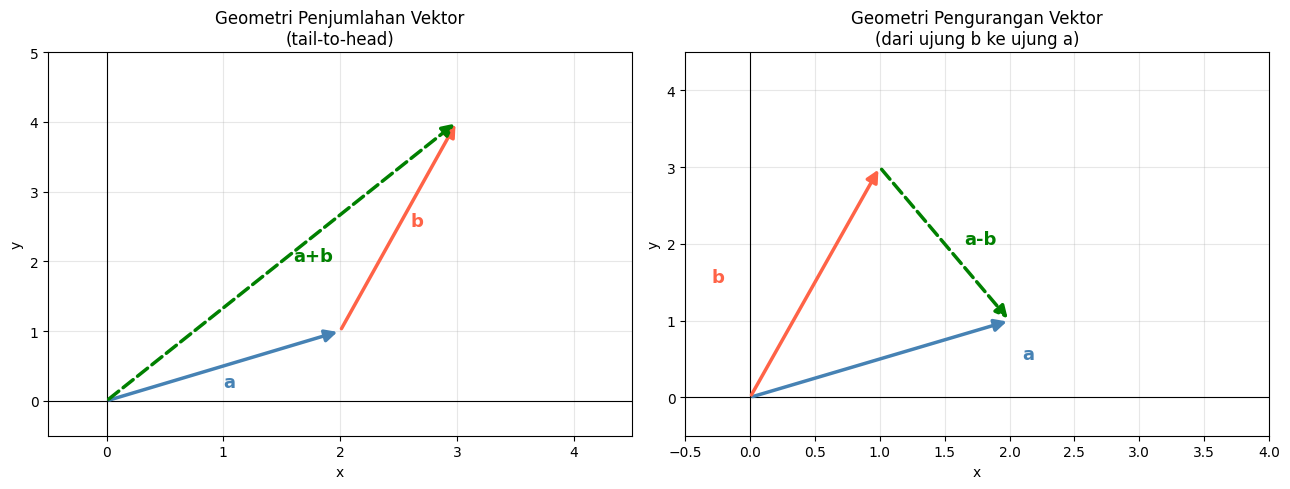

In [6]:
# Visualisasi geometri penjumlahan dan pengurangan vektor
a = np.array([2, 1])
b = np.array([1, 3])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel kiri: penjumlahan
ax = axes[0]
# Gambar a
ax.annotate("", xy=a, xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.5, mutation_scale=18))
ax.text(a[0]/2, a[1]/2 - 0.3, "a", color="steelblue", fontsize=13, fontweight="bold")

# Gambar b mulai dari ujung a (tail-to-head)
ax.annotate("", xy=a+b, xytext=a,
            arrowprops=dict(arrowstyle="-|>", color="tomato", lw=2.5, mutation_scale=18))
ax.text(a[0]+b[0]/2+0.1, a[1]+b[1]/2, "b", color="tomato", fontsize=13, fontweight="bold")

# Gambar vektor hasil (a+b)
ax.annotate("", xy=a+b, xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="green", lw=2.5,
                            mutation_scale=18, linestyle="dashed"))
ax.text((a+b)[0]/2+0.1, (a+b)[1]/2, "a+b", color="green", fontsize=13, fontweight="bold")

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 5)
ax.grid(True, alpha=0.3)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Geometri Penjumlahan Vektor\n(tail-to-head)")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Panel kanan: pengurangan
ax = axes[1]
# Gambar a dan b dari asal yang sama
ax.annotate("", xy=a, xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.5, mutation_scale=18))
ax.text(a[0]+0.1, a[1]/2, "a", color="steelblue", fontsize=13, fontweight="bold")

ax.annotate("", xy=b, xytext=(0,0),
            arrowprops=dict(arrowstyle="-|>", color="tomato", lw=2.5, mutation_scale=18))
ax.text(-0.3, b[1]/2, "b", color="tomato", fontsize=13, fontweight="bold")

# Vektor selisih: dari ujung b ke ujung a
ax.annotate("", xy=a, xytext=b,
            arrowprops=dict(arrowstyle="-|>", color="green", lw=2.5,
                            mutation_scale=18, linestyle="dashed"))
ax.text((a[0]+b[0])/2 + 0.15, (a[1]+b[1])/2, "a-b", color="green",
        fontsize=13, fontweight="bold")

ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 4.5)
ax.grid(True, alpha=0.3)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Geometri Pengurangan Vektor\n(dari ujung b ke ujung a)")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()

### 2.3.2 Perkalian Vektor-Skalar

Skalar dalam aljabar linear adalah sebuah angka tunggal yang tidak tertanam
dalam vektor atau matriks. Biasanya dilambangkan dengan huruf Yunani kecil seperti
lambda, alpha, atau beta.

Perkalian vektor-skalar sangat sederhana: kalikan setiap elemen vektor dengan skalar.

Mengapa disebut "skalar"? Karena skalar men-skala (mengubah ukuran) vektor
tanpa mengubah arahnya. Efek skalar:
- Skalar > 1: memperpanjang vektor
- 0 < skalar < 1: memperpendek vektor
- Skalar = 0: menghasilkan vektor nol
- Skalar negatif: membalik arah vektor (rotasi 180 derajat)

In [7]:
# Perkalian vektor-skalar
w = np.array([9, 4, 1])

print("=== Perkalian Vektor-Skalar ===")
print(f"w = {w}")
print()
for lam in [4, 0.5, 0, -1, -2]:
    result = lam * w
    print(f"  lambda={lam:4}  -->  lambda*w = {result}")
print()

# Penting: perbedaan perilaku List vs NumPy array
s = 2
a_list  = [3, 4, 5]
b_array = np.array(a_list)

print("=== List vs NumPy Array saat Dikali Skalar ===")
print(f"s = {s}")
print(f"a_list  * s = {a_list * s}  <-- BUKAN perkalian aljabar! List direpetisi.")
print(f"b_array * s = {b_array * s}  <-- Perkalian aljabar yang benar.")
print()
print("KESIMPULAN: Selalu gunakan NumPy array untuk operasi aljabar linear!")

=== Perkalian Vektor-Skalar ===
w = [9 4 1]

  lambda=   4  -->  lambda*w = [36 16  4]
  lambda= 0.5  -->  lambda*w = [4.5 2.  0.5]
  lambda=   0  -->  lambda*w = [0 0 0]
  lambda=  -1  -->  lambda*w = [-9 -4 -1]
  lambda=  -2  -->  lambda*w = [-18  -8  -2]

=== List vs NumPy Array saat Dikali Skalar ===
s = 2
a_list  * s = [3, 4, 5, 3, 4, 5]  <-- BUKAN perkalian aljabar! List direpetisi.
b_array * s = [ 6  8 10]  <-- Perkalian aljabar yang benar.

KESIMPULAN: Selalu gunakan NumPy array untuk operasi aljabar linear!


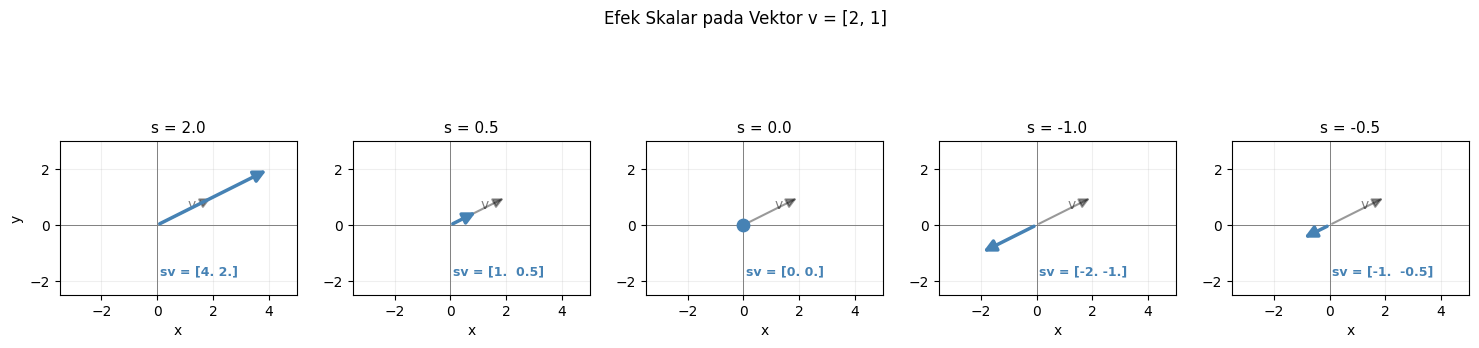

In [8]:
# Visualisasi efek berbagai skalar pada vektor
v_base = np.array([2, 1])
scalars = [2.0, 0.5, 0.0, -1.0, -0.5]

fig, axes = plt.subplots(1, len(scalars), figsize=(15, 4))

for ax, s in zip(axes, scalars):
    v_scaled = s * v_base

    # Gambar vektor asli (hitam tipis)
    ax.annotate("", xy=v_base, xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5,
                                mutation_scale=15, alpha=0.4))
    ax.text(v_base[0]/2+0.1, v_base[1]/2+0.1, "v", color="black",
            fontsize=10, alpha=0.5)

    # Gambar vektor yang di-skala (warna)
    if np.any(v_scaled != 0):
        ax.annotate("", xy=v_scaled, xytext=(0,0),
                    arrowprops=dict(arrowstyle="-|>", color="steelblue",
                                    lw=2.5, mutation_scale=18))
    else:
        ax.scatter([0], [0], color="steelblue", s=80, zorder=5)

    ax.text(0.1, -1.8, f"sv = {v_scaled}", color="steelblue",
            fontsize=9, fontweight="bold")

    ax.set_xlim(-3.5, 5)
    ax.set_ylim(-2.5, 3)
    ax.axhline(0, color="gray", linewidth=0.7)
    ax.axvline(0, color="gray", linewidth=0.7)
    ax.grid(True, alpha=0.2)
    ax.set_title(f"s = {s}", fontsize=11)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    if ax == axes[0]:
        ax.set_ylabel("y")

plt.suptitle("Efek Skalar pada Vektor v = [2, 1]", fontsize=12)
plt.tight_layout()
plt.show()

### 2.3.3 Scalar-Vector Addition

Penjumlahan skalar ke vektor secara formal tidak terdefinisi dalam aljabar linear
(karena keduanya adalah objek matematika yang berbeda). Namun Python akan mengizinkan
ini dan menambahkan skalar ke setiap elemen vektor -- setara dengan scalar-vector multiplication.

In [9]:
# Scalar-Vector Addition (penjumlahan skalar ke vektor)
s = 2
v = np.array([3, 6])

result = s + v

print("=== Scalar-Vector Addition ===")
print(f"s = {s}")
print(f"v = {v}")
print(f"s + v = {result}")
print()
print("Python menambahkan skalar ke setiap elemen vektor.")
print("Ini bukan operasi resmi aljabar linear, tapi berguna dalam coding.")

=== Scalar-Vector Addition ===
s = 2
v = [3 6]
s + v = [5 8]

Python menambahkan skalar ke setiap elemen vektor.
Ini bukan operasi resmi aljabar linear, tapi berguna dalam coding.


### 2.3.4 Transpose

Operasi transpose mengubah vektor kolom menjadi vektor baris, dan sebaliknya.

Definisi formal: elemen pada posisi (i,j) dipindahkan ke posisi (j,i).

    m^T_{i,j} = m_{j,i}

Aturan penting: transpose dua kali menghasilkan vektor semula: (v^T)^T = v

Notasi transpose: vektor v yang ditranspose ditulis v^T (dibaca "v transpose").
Konvensi aljabar linear: kecuali disebutkan lain, vektor diasumsikan berorientasi kolom.

In [10]:
# Operasi transpose pada vektor
col_vec = np.array([[1], [2], [3], [4]])  # kolom: shape (4,1)
row_vec = np.array([[1, 2, 3, 4]])        # baris: shape (1,4)

print("=== Transpose Vektor ===")
print(f"col_vec (shape {col_vec.shape}):")
print(col_vec)
print(f"col_vec.T (shape {col_vec.T.shape}):")
print(col_vec.T)
print()
print(f"row_vec (shape {row_vec.shape}):")
print(row_vec)
print(f"row_vec.T (shape {row_vec.T.shape}):")
print(row_vec.T)
print()

# Transpose dua kali menghasilkan vektor semula
v_original = np.array([[5], [10], [15]])
v_double_T = v_original.T.T
print("=== Transpose Dua Kali ===")
print(f"v           : {v_original.ravel()}")
print(f"(v^T)^T     : {v_double_T.ravel()}")
print(f"Identik?    : {np.allclose(v_original, v_double_T)}")

=== Transpose Vektor ===
col_vec (shape (4, 1)):
[[1]
 [2]
 [3]
 [4]]
col_vec.T (shape (1, 4)):
[[1 2 3 4]]

row_vec (shape (1, 4)):
[[1 2 3 4]]
row_vec.T (shape (4, 1)):
[[1]
 [2]
 [3]
 [4]]

=== Transpose Dua Kali ===
v           : [ 5 10 15]
(v^T)^T     : [ 5 10 15]
Identik?    : True


## 2.4 Vector Broadcasting di Python

Broadcasting adalah operasi yang hanya ada di aljabar linear berbasis komputer
modern, tidak ditemukan dalam textbook tradisional.

Broadcasting berarti mengulang operasi antara satu vektor dan setiap elemen
vektor lainnya. Ini memungkinkan komputasi yang efisien dan compact.

### Cara Kerja Broadcasting

Ketika menjumlahkan vektor kolom (N,1) dengan vektor baris (1,M),
NumPy secara otomatis memperluas (broadcast) keduanya menjadi matriks (N,M)
dan melakukan operasi elemen demi elemen.

In [11]:
# Broadcasting: penjumlahan vektor kolom dengan vektor baris
v_col = np.array([[1], [2], [3]])   # shape (3,1)
w_row = np.array([[10, 20]])         # shape (1,2)

result_broadcast = v_col + w_row     # shape (3,2)

print("=== Vector Broadcasting ===")
print(f"v_col shape: {v_col.shape}")
print(f"v_col:\\n{v_col}")
print()
print(f"w_row shape: {w_row.shape}")
print(f"w_row: {w_row}")
print()
print(f"v_col + w_row shape: {result_broadcast.shape}")
print(f"Hasil broadcasting:\\n{result_broadcast}")
print()
print("Interpretasi: setiap elemen v_col ditambahkan ke seluruh baris w_row.")
print()

# Orientasi penting untuk broadcasting!
v_row = np.array([[1, 2, 3]])    # shape (1,3) -- row vector
w_col = np.array([[10], [20]])   # shape (2,1) -- col vector

result2 = v_row + w_col
print(f"v_row (shape {v_row.shape}) + w_col (shape {w_col.shape}) = shape {result2.shape}")
print(result2)
print()
print("Orientasi berpengaruh pada hasil! Pastikan orientasi sudah benar.")

=== Vector Broadcasting ===
v_col shape: (3, 1)
v_col:\n[[1]
 [2]
 [3]]

w_row shape: (1, 2)
w_row: [[10 20]]

v_col + w_row shape: (3, 2)
Hasil broadcasting:\n[[11 21]
 [12 22]
 [13 23]]

Interpretasi: setiap elemen v_col ditambahkan ke seluruh baris w_row.

v_row (shape (1, 3)) + w_col (shape (2, 1)) = shape (2, 3)
[[11 12 13]
 [21 22 23]]

Orientasi berpengaruh pada hasil! Pastikan orientasi sudah benar.


## 2.5 Magnitude Vektor dan Unit Vector

### Magnitude (Norm) Vektor

Magnitude vektor adalah jarak geometris dari tail ke head, dihitung menggunakan
rumus Euclidean distance: akar kuadrat dari jumlah kuadrat semua elemen.

    ||v|| = sqrt(sum(v_i^2))

Notasi: magnitude ditulis dengan dua batang vertikal di sekitar vektor: ||v||.

Perhatian terminologi Python vs Matematika:
- Matematika: "panjang (length)" = jarak geometris
- Python `len()`: mengembalikan jumlah elemen (dimensionalitas matematis)
- Python `np.linalg.norm()`: mengembalikan jarak geometris (magnitude matematis)

### Unit Vector

Unit vector adalah vektor yang memiliki panjang geometris tepat 1 (||v|| = 1).

Membuat unit vector dari vektor apapun: scalar multiply dengan kebalikan normanya.

    v_hat = (1 / ||v||) * v

Satu-satunya vektor yang tidak memiliki unit vector terkait: **vektor nol**,
karena tidak memiliki arah dan tidak bisa di-skala ke panjang non-nol.

In [12]:
# Magnitude vektor dan unit vector
v = np.array([1, 2, 3, 7, 8, 9])

# Magnitude
v_dim = len(v)         # dimensionalitas (jumlah elemen) -- Python "length"
v_mag = np.linalg.norm(v)  # magnitude geometris (jarak)

print("=== Magnitude Vektor ===")
print(f"v = {v}")
print(f"len(v) = {v_dim}  (jumlah elemen / dimensionalitas)")
print(f"||v||  = {v_mag:.4f}  (magnitude geometris / norm)")
print()
print("Hitung manual: sqrt(" + " + ".join([f"{x}^2" for x in v]) + ")")
v_mag_manual = np.sqrt(np.sum(v**2))
print(f"  = sqrt({np.sum(v**2)}) = {v_mag_manual:.4f}")
print()

# Unit vector
v_unit = v / np.linalg.norm(v)
v_unit_norm = np.linalg.norm(v_unit)

print("=== Unit Vector ===")
print(f"v_hat = v / ||v|| = {v_unit.round(4)}")
print(f"||v_hat|| = {v_unit_norm:.6f}  (harus = 1.0)")
print()
print("Verifikasi: apakah v dan v_hat memiliki arah yang sama?")
print(f"v_hat / v_hat[0] = {(v_unit / v_unit[0]).round(4)}")
print(f"v     / v[0]     = {(v / v[0]).round(4)}")
print("Proporsi elemen sama --> arah sama!")

=== Magnitude Vektor ===
v = [1 2 3 7 8 9]
len(v) = 6  (jumlah elemen / dimensionalitas)
||v||  = 14.4222  (magnitude geometris / norm)

Hitung manual: sqrt(1^2 + 2^2 + 3^2 + 7^2 + 8^2 + 9^2)
  = sqrt(208) = 14.4222

=== Unit Vector ===
v_hat = v / ||v|| = [0.0693 0.1387 0.208  0.4854 0.5547 0.624 ]
||v_hat|| = 1.000000  (harus = 1.0)

Verifikasi: apakah v dan v_hat memiliki arah yang sama?
v_hat / v_hat[0] = [1. 2. 3. 7. 8. 9.]
v     / v[0]     = [1. 2. 3. 7. 8. 9.]
Proporsi elemen sama --> arah sama!


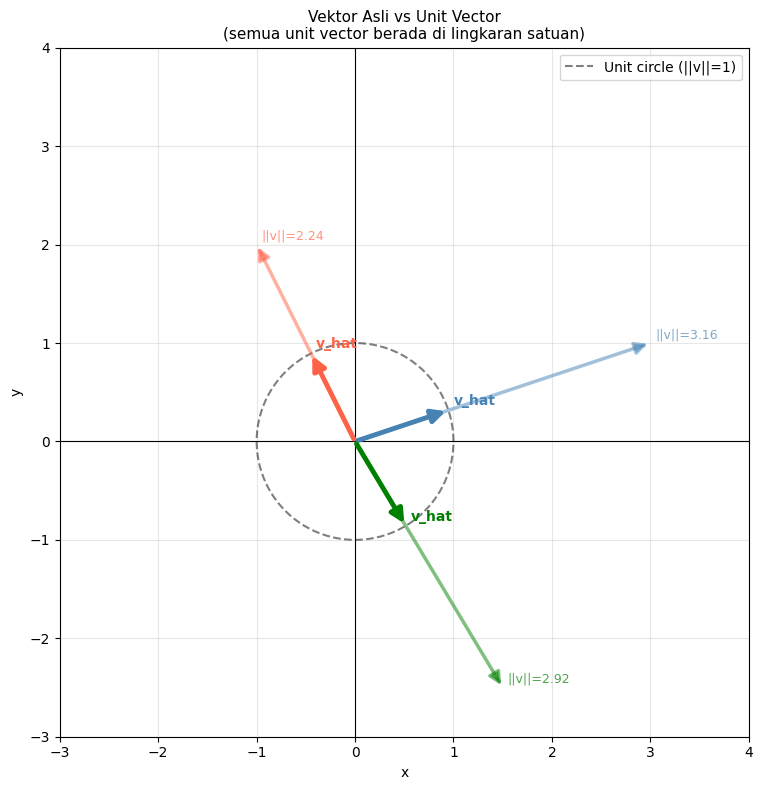

In [13]:
# Visualisasi: vektor asli vs unit vector (2D)
vectors_2d = [
    np.array([3.0, 1.0]),
    np.array([-1.0, 2.0]),
    np.array([1.5, -2.5]),
]

fig, ax = plt.subplots(figsize=(8, 8))

colors = ["steelblue", "tomato", "green"]

for vec, color in zip(vectors_2d, colors):
    unit_vec = vec / np.linalg.norm(vec)
    mag = np.linalg.norm(vec)

    # Gambar vektor asli
    ax.annotate("", xy=vec, xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.5,
                                mutation_scale=18, alpha=0.5))

    # Gambar unit vector (lebih tebal)
    ax.annotate("", xy=unit_vec, xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=3.5,
                                mutation_scale=20))

    ax.text(vec[0]+0.05, vec[1]+0.05, f"||v||={mag:.2f}", color=color,
            fontsize=9, alpha=0.7)
    ax.text(unit_vec[0]+0.05, unit_vec[1]+0.05, "v_hat", color=color,
            fontsize=10, fontweight="bold")

# Lingkaran satuan
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=1.5, alpha=0.5,
        label="Unit circle (||v||=1)")

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-3, 4)
ax.set_ylim(-3, 4)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_title("Vektor Asli vs Unit Vector\n(semua unit vector berada di lingkaran satuan)", fontsize=11)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## 2.6 The Vector Dot Product (Perkalian Dalam)

Dot product adalah salah satu operasi paling penting dalam seluruh aljabar linear.
Ia adalah blok bangunan komputasi dasar dari banyak operasi dan algoritma, termasuk:
- Konvolusi dan korelasi
- Transformasi Fourier
- Perkalian matriks
- Ekstraksi fitur linear
- Filter sinyal

### Definisi Dot Product

Untuk menghitung dot product: kalikan elemen-elemen yang bersesuaian, kemudian
jumlahkan semua hasil perkalian tersebut.

    delta = sum(a_i * b_i)  untuk i = 1, ..., n

Dot product hanya valid untuk dua vektor dengan dimensionalitas yang sama.

### Interpretasi Geometri

Ada juga definisi geometris dot product:

    alpha = cos(theta) * ||v|| * ||w||

di mana theta adalah sudut antara dua vektor.

Ini berarti tanda dot product ditentukan sepenuhnya oleh hubungan geometris
antara dua vektor (melalui cos(theta)):
- cos(theta) > 0: sudut < 90 derajat (vektor "condong ke arah yang sama")
- cos(theta) = 0: sudut = 90 derajat (vektor tegak lurus / ortogonal)
- cos(theta) < 0: sudut > 90 derajat (vektor "condong ke arah berlawanan")

**PENTING DIINGAT: Vektor yang ortogonal memiliki dot product = 0.**

In [14]:
# Menghitung dot product
v = np.array([1, 2, 3, 4])
w = np.array([5, 6, 7, 8])

# Cara 1: menggunakan np.dot()
dot1 = np.dot(v, w)

# Cara 2: manual (element-wise multiply then sum)
dot2 = np.sum(v * w)

# Cara 3: menggunakan operator @ (matrix multiplication operator)
dot3 = v @ w

print("=== Dot Product ===")
print(f"v = {v}")
print(f"w = {w}")
print()
print("Perhitungan manual:")
terms = " + ".join([f"{a}*{b}" for a,b in zip(v,w)])
print(f"  {terms}")
print(f"  = {' + '.join([str(a*b) for a,b in zip(v,w)])}")
print(f"  = {dot1}")
print()
print(f"np.dot(v, w)  = {dot1}")
print(f"sum(v * w)    = {dot2}")
print(f"v @ w         = {dot3}")
print()
print("Ketiga cara memberikan hasil yang sama!")

=== Dot Product ===
v = [1 2 3 4]
w = [5 6 7 8]

Perhitungan manual:
  1*5 + 2*6 + 3*7 + 4*8
  = 5 + 12 + 21 + 32
  = 70

np.dot(v, w)  = 70
sum(v * w)    = 70
v @ w         = 70

Ketiga cara memberikan hasil yang sama!


In [16]:
#Sifat distributif dot product: a^T(b+c) = a^T*b + a^T*c
a = np.array([0, 1, 2])
b = np.array([3, 5, 8])
c = np.array([13, 21, 34])

lhs = np.dot(a, b + c)       # a . (b+c)
rhs = np.dot(a, b) + np.dot(a, c)  # a.b + a.c

print("=== Sifat Distributif Dot Product ===")
print(f"a = {a}")
print(f"b = {b}")
print(f"c = {c}")
print()
print(f"a . (b+c)     = {lhs}")
print(f"a.b + a.c     = {rhs}")
print(f"Identik?      : {np.isclose(lhs, rhs)}")
print()

# Pengaruh scalar multiplication terhadap dot product
s = 10
print("=== Pengaruh Scalar Multiplication ===")
print(f"v . w         = {np.dot(v, w)}")
print(f"(s*v) . w     = {np.dot(s*v, w)}  (= s * (v.w) = {s} * {np.dot(v,w)})")
print(f"(-v) . w      = {np.dot(-v, w)}  (membalik tanda)")
print(f"0*v . w       = {np.dot(0*v, w)}  (= 0)")

=== Sifat Distributif Dot Product ===
a = [0 1 2]
b = [3 5 8]
c = [13 21 34]

a . (b+c)     = 110
a.b + a.c     = 110
Identik?      : True

=== Pengaruh Scalar Multiplication ===
v . w         = 70
(s*v) . w     = 700  (= s * (v.w) = 10 * 70)
(-v) . w      = -70  (membalik tanda)
0*v . w       = 0  (= 0)


In [19]:
# Interpretasi geometri dot product: sudut antara vektor
def angle_between(v1, v2):
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cos_angle = np.clip(cos_angle, -1, 1)  # clamp untuk stabilitas numerik
    return np.degrees(np.arccos(cos_angle))

# Beberapa pasang vektor dengan berbagai sudut
pairs = [
    (np.array([1, 0]), np.array([1, 0]),   "sama persis (0 derajat)"),
    (np.array([1, 0]), np.array([0, 1]),   "ortogonal (90 derajat)"),
    (np.array([1, 0]), np.array([-1, 0]),  "berlawanan (180 derajat)"),
    (np.array([1, 0]), np.array([1, 1]),   "sudut 45 derajat"),
    (np.array([2, 1]), np.array([1, 3]),   "sudut sembarang"),
]

print("=== Hubungan Dot Product dan Sudut Antar Vektor ===")
print(f"{'Deskripsi':<30} {'Dot Product':>12} {'Sudut (derajat)':>17} {'Tanda':>6}")
print("-" * 70)
for v1, v2, desc in pairs:
    dp = np.dot(v1, v2)
    angle = angle_between(v1, v2)
    sign = "+" if dp > 0 else ("-" if dp < 0 else "0")
    print(f"{desc:<30} {dp:>12.4f} {angle:>17.2f} {sign:>6}")

print()
print("Kesimpulan:")
print("  Dot product > 0: sudut < 90 derajat (same side)")
print("  Dot product = 0: sudut = 90 derajat (ortogonal)")
print("  Dot product < 0: sudut > 90 derajat (opposite side)")

=== Hubungan Dot Product dan Sudut Antar Vektor ===
Deskripsi                       Dot Product   Sudut (derajat)  Tanda
----------------------------------------------------------------------
sama persis (0 derajat)              1.0000              0.00      +
ortogonal (90 derajat)               0.0000             90.00      0
berlawanan (180 derajat)            -1.0000            180.00      -
sudut 45 derajat                     1.0000             45.00      +
sudut sembarang                      5.0000             45.00      +

Kesimpulan:
  Dot product > 0: sudut < 90 derajat (same side)
  Dot product = 0: sudut = 90 derajat (ortogonal)
  Dot product < 0: sudut > 90 derajat (opposite side)


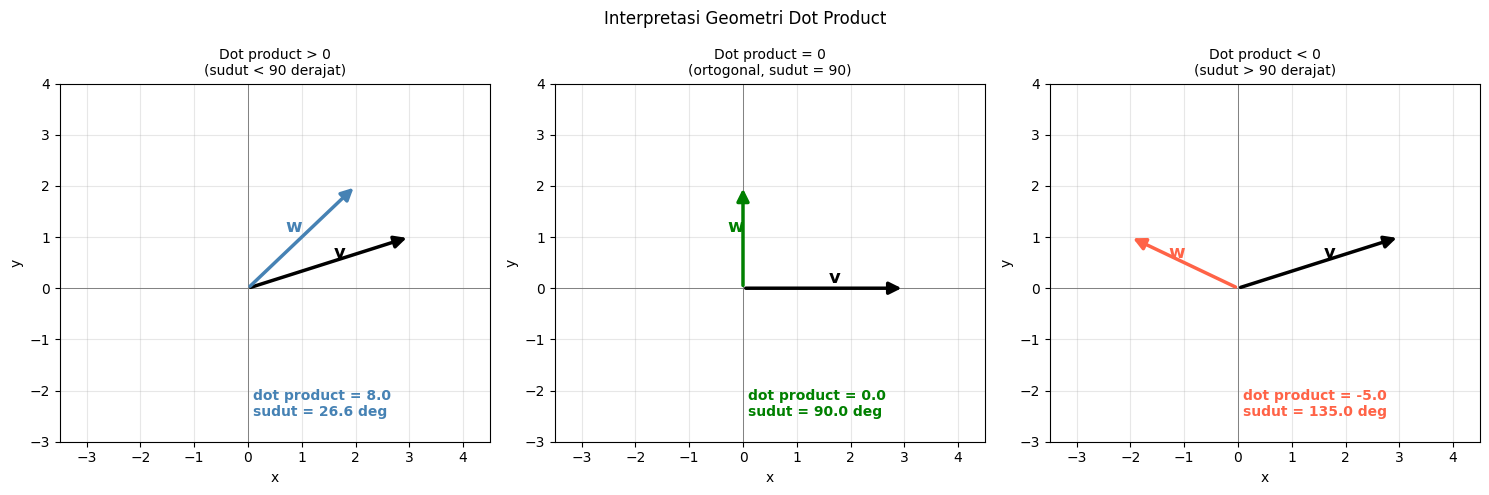

In [20]:
# Visualisasi interpretasi geometri dot product
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cases = [
    (np.array([3, 1]), np.array([2, 2]), "Dot product > 0\n(sudut < 90 derajat)", "steelblue"),
    (np.array([3, 0]), np.array([0, 2]), "Dot product = 0\n(ortogonal, sudut = 90)", "green"),
    (np.array([3, 1]), np.array([-2, 1]), "Dot product < 0\n(sudut > 90 derajat)", "tomato"),
]

for ax, (v1, v2, title, color) in zip(axes, cases):
    dp = np.dot(v1, v2)
    angle = angle_between(v1, v2)

    ax.annotate("", xy=v1, xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.5, mutation_scale=18))
    ax.text(v1[0]/2+0.1, v1[1]/2+0.1, "v", color="black", fontsize=13, fontweight="bold")

    ax.annotate("", xy=v2, xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.5, mutation_scale=18))
    ax.text(v2[0]/2-0.3, v2[1]/2+0.1, "w", color=color, fontsize=13, fontweight="bold")

    ax.text(0.1, -2.5, f"dot product = {dp:.1f}\nsudut = {angle:.1f} deg",
            fontsize=10, color=color, fontweight="bold")

    ax.axhline(0, color="gray", linewidth=0.7)
    ax.axvline(0, color="gray", linewidth=0.7)
    ax.set_xlim(-3.5, 4.5)
    ax.set_ylim(-3, 4)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Interpretasi Geometri Dot Product", fontsize=12)
plt.tight_layout()
plt.show()

## 2.7 Perkalian Vektor Lainnya

Selain dot product, ada beberapa cara lain untuk mengalikan vektor.

### 2.7.1 Hadamard Multiplication (Element-wise Multiplication)

Hadamard multiplication adalah istilah mewah untuk perkalian elemen demi elemen.
Setiap elemen yang bersesuaian dalam dua vektor dikalikan, menghasilkan vektor
dengan dimensionalitas yang sama.

Notasi: a hadamard b = a circle b

Syarat: kedua vektor harus memiliki dimensionalitas yang sama.

Contoh kegunaan: menghitung revenue per toko dari vektor jumlah produk dan
vektor harga per produk.

### 2.7.2 Outer Product

Outer product menghasilkan matriks dari vektor kolom dan vektor baris.
Setiap baris dalam matriks hasil adalah vektor baris yang dikalikan secara skalar
dengan elemen yang bersesuaian dalam vektor kolom.

Notasi: v * w^T

Perbedaan penting dengan dot product:
- Dot product: menghasilkan skalar, kedua vektor harus sama dimensinya
- Outer product: menghasilkan matriks, dua vektor boleh berbeda dimensinya

In [21]:
# Hadamard multiplication (element-wise)
a = np.array([5, 4, 8, 2])
b = np.array([1, 0, 0.5, -1])

hadamard_result = a * b  # operator * untuk element-wise di NumPy

print("=== Hadamard Multiplication ===")
print(f"a = {a}")
print(f"b = {b}")
print(f"a hadamard b = {hadamard_result}")
print()
print("Verifikasi elemen demi elemen:")
for i in range(len(a)):
    print(f"  elemen {i}: {a[i]} * {b[i]} = {a[i]*b[i]}")
print()

# Contoh kegunaan: revenue per toko
jumlah_produk = np.array([100, 250, 75, 180])   # produk terjual per toko
harga_per_produk = np.array([50000, 25000, 80000, 35000])  # harga per produk
revenue_per_toko = jumlah_produk * harga_per_produk

print("=== Contoh Nyata: Revenue per Toko ===")
for i, rev in enumerate(revenue_per_toko):
    print(f"  Toko {i+1}: {jumlah_produk[i]} produk x Rp{harga_per_produk[i]:,} = Rp{rev:,}")
print(f"Total revenue: Rp{revenue_per_toko.sum():,}")
print(f"(Bandingkan: dot product = total revenue = {np.dot(jumlah_produk, harga_per_produk):,})")

=== Hadamard Multiplication ===
a = [5 4 8 2]
b = [ 1.   0.   0.5 -1. ]
a hadamard b = [ 5.  0.  4. -2.]

Verifikasi elemen demi elemen:
  elemen 0: 5 * 1.0 = 5.0
  elemen 1: 4 * 0.0 = 0.0
  elemen 2: 8 * 0.5 = 4.0
  elemen 3: 2 * -1.0 = -2.0

=== Contoh Nyata: Revenue per Toko ===
  Toko 1: 100 produk x Rp50,000 = Rp5,000,000
  Toko 2: 250 produk x Rp25,000 = Rp6,250,000
  Toko 3: 75 produk x Rp80,000 = Rp6,000,000
  Toko 4: 180 produk x Rp35,000 = Rp6,300,000
Total revenue: Rp23,550,000
(Bandingkan: dot product = total revenue = 23,550,000)


In [22]:
# Outer Product
col = np.array([[1], [2], [3]])   # vektor kolom (3,1)
row = np.array([[4, 5, 6, 7]])    # vektor baris (1,4)

outer1 = np.outer(col, row)       # menggunakan np.outer()
outer2 = col @ row                # menggunakan matrix multiplication

print("=== Outer Product ===")
print(f"col (shape {col.shape}):\\n{col}")
print(f"row (shape {row.shape}): {row}")
print()
print(f"Outer product (shape {outer1.shape}):")
print(outer1)
print()
print("Verifikasi pola:")
print("  Setiap baris = baris row dikali elemen yang bersesuaian dari col")
print(f"  Baris 0 = {col[0,0]} * {row} = {col[0,0] * row}")
print(f"  Baris 1 = {col[1,0]} * {row} = {col[1,0] * row}")
print(f"  Baris 2 = {col[2,0]} * {row} = {col[2,0] * row}")

=== Outer Product ===
col (shape (3, 1)):\n[[1]
 [2]
 [3]]
row (shape (1, 4)): [[4 5 6 7]]

Outer product (shape (3, 4)):
[[ 4  5  6  7]
 [ 8 10 12 14]
 [12 15 18 21]]

Verifikasi pola:
  Setiap baris = baris row dikali elemen yang bersesuaian dari col
  Baris 0 = 1 * [[4 5 6 7]] = [[4 5 6 7]]
  Baris 1 = 2 * [[4 5 6 7]] = [[ 8 10 12 14]]
  Baris 2 = 3 * [[4 5 6 7]] = [[12 15 18 21]]


## 2.8 Orthogonal Vector Decomposition (Dekomposisi Vektor Ortogonal)

### Konsep Dekomposisi

"Mendekomposisi" berarti memecah sesuatu menjadi bagian-bagian yang lebih sederhana.
Ini adalah konsep sentral dalam aljabar linear.

Contoh sederhana:
- Mendekomposisi 42.01 menjadi 42 (bilangan bulat) + 0.01 (desimal)
- Mendekomposisi 42 menjadi faktor prima: 2 * 3 * 7

### Dekomposisi Vektor Ortogonal

Kita bisa memecah satu vektor menjadi dua komponen:
1. Satu komponen yang **paralel** dengan vektor referensi
2. Satu komponen yang **ortogonal** (tegak lurus) terhadap vektor referensi

### Masalah: Proyeksi Vektor

Diberikan dua vektor a dan b, cari titik di vektor a yang paling dekat
dengan kepala (head) dari b. Titik tersebut adalah beta*a.

Kita perlu menemukan skalar beta yang meminimalkan jarak projeksi.

### Solusi: Proyeksi Ortogonal

Kunci solusinya: komponen residual (b - beta*a) harus **ortogonal** terhadap a.
Karena dua vektor ortogonal memiliki dot product = 0:

    a^T (b - beta*a) = 0
    a^T b - beta * a^T a = 0
    beta = (a^T b) / (a^T a)

Setelah menemukan beta:
- **Komponen paralel**: beta * a  (proyeksi b ke a)
- **Komponen ortogonal**: b - beta * a  (sisa dari proyeksi)

Dekomposisi ini langsung mengarah ke prosedur Gram-Schmidt dan Dekomposisi QR,
yang sangat penting dalam statistik dan pemrosesan sinyal.

In [23]:
# Dekomposisi vektor ortogonal
a = np.array([3.0, 1.0])   # vektor referensi
b = np.array([2.0, 3.0])   # vektor yang akan didekomposisi

# Hitung beta (skalar proyeksi)
beta = np.dot(a, b) / np.dot(a, a)

# Komponen paralel dan ortogonal
b_parallel  = beta * a           # komponen sejajar a
b_orthogonal = b - b_parallel    # komponen tegak lurus a

print("=== Orthogonal Vector Decomposition ===")
print(f"a = {a}  (vektor referensi)")
print(f"b = {b}  (vektor yang didekomposisi)")
print()
print(f"beta = (a.b) / (a.a) = {np.dot(a,b):.4f} / {np.dot(a,a):.4f} = {beta:.4f}")
print()
print(f"b_parallel   = beta * a = {b_parallel.round(4)}")
print(f"b_orthogonal = b - b_parallel = {b_orthogonal.round(4)}")
print()
print("Verifikasi:")
print(f"  b_parallel + b_orthogonal = {(b_parallel + b_orthogonal).round(4)}  (harus = b = {b})")
print(f"  Rekonstruksi benar? {np.allclose(b_parallel + b_orthogonal, b)}")
print()
print(f"  Dot product a . b_orthogonal = {np.dot(a, b_orthogonal):.6f}  (harus = 0)")
print(f"  Ortogonal? {np.isclose(np.dot(a, b_orthogonal), 0)}")

=== Orthogonal Vector Decomposition ===
a = [3. 1.]  (vektor referensi)
b = [2. 3.]  (vektor yang didekomposisi)

beta = (a.b) / (a.a) = 9.0000 / 10.0000 = 0.9000

b_parallel   = beta * a = [2.7 0.9]
b_orthogonal = b - b_parallel = [-0.7  2.1]

Verifikasi:
  b_parallel + b_orthogonal = [2. 3.]  (harus = b = [2. 3.])
  Rekonstruksi benar? True

  Dot product a . b_orthogonal = -0.000000  (harus = 0)
  Ortogonal? True


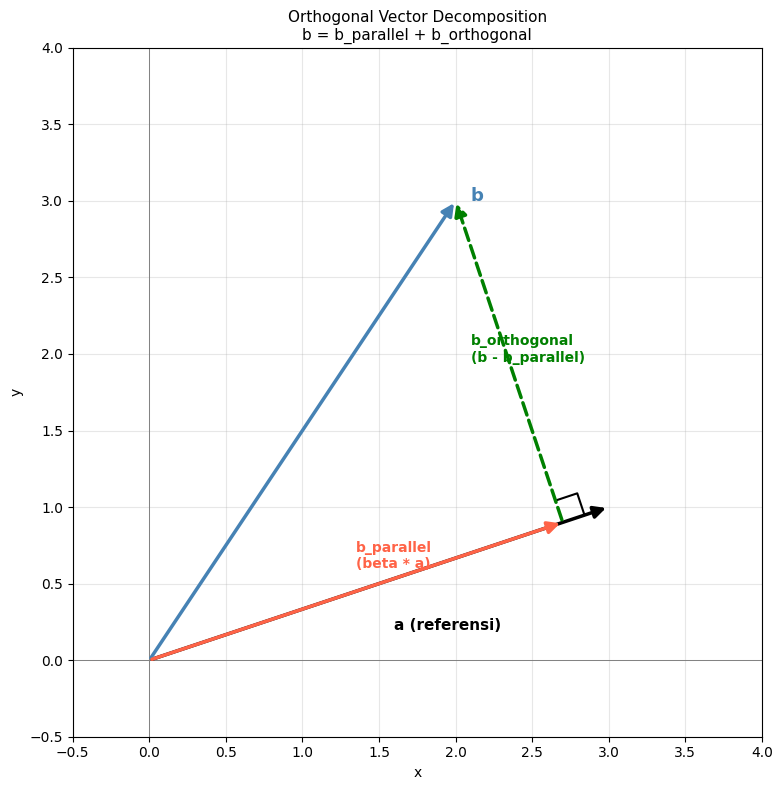

In [24]:
# Visualisasi dekomposisi vektor ortogonal
fig, ax = plt.subplots(figsize=(9, 8))

origin = np.array([0, 0])

# Gambar vektor a (referensi)
ax.annotate("", xy=a, xytext=origin,
            arrowprops=dict(arrowstyle="-|>", color="black", lw=2.5, mutation_scale=18))
ax.text(a[0]/2+0.1, a[1]/2-0.3, "a (referensi)", color="black", fontsize=11, fontweight="bold")

# Gambar vektor b
ax.annotate("", xy=b, xytext=origin,
            arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.5, mutation_scale=18))
ax.text(b[0]+0.1, b[1], "b", color="steelblue", fontsize=13, fontweight="bold")

# Gambar komponen paralel (proyeksi)
ax.annotate("", xy=b_parallel, xytext=origin,
            arrowprops=dict(arrowstyle="-|>", color="tomato", lw=2.5, mutation_scale=18))
ax.text(b_parallel[0]/2, b_parallel[1]-0.3, "b_parallel\n(beta * a)", color="tomato",
        fontsize=10, fontweight="bold")

# Gambar komponen ortogonal (dari b_parallel ke b)
ax.annotate("", xy=b, xytext=b_parallel,
            arrowprops=dict(arrowstyle="-|>", color="green", lw=2.5,
                            mutation_scale=18, linestyle="dashed"))
ax.text(b[0]+0.1, (b[1]+b_parallel[1])/2, "b_orthogonal\n(b - b_parallel)",
        color="green", fontsize=10, fontweight="bold")

# Gambar garis sudut siku-siku (indikator ortogonal)
corner_size = 0.15
corner_dir = b_orthogonal / np.linalg.norm(b_orthogonal) * corner_size
a_dir = a / np.linalg.norm(a) * corner_size
corner_pts = np.array([
    b_parallel + corner_dir,
    b_parallel + corner_dir + a_dir,
    b_parallel + a_dir
])
ax.plot(corner_pts[:, 0], corner_pts[:, 1], "k-", linewidth=1.5)

ax.axhline(0, color="gray", linewidth=0.7)
ax.axvline(0, color="gray", linewidth=0.7)
ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 4)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.set_title("Orthogonal Vector Decomposition\nb = b_parallel + b_orthogonal", fontsize=11)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

In [25]:
# Aplikasi: dekomposisi pada vektor acak (verifikasi sifat umum)
print("=== Verifikasi Sifat Dekomposisi Ortogonal (Multi-Trial) ===")
print()

all_correct = True
for trial in range(8):
    a_rand = np.random.randn(5)   # vektor referensi acak di R^5
    b_rand = np.random.randn(5)   # vektor yang didekomposisi acak

    beta_rand       = np.dot(a_rand, b_rand) / np.dot(a_rand, a_rand)
    b_par           = beta_rand * a_rand
    b_orth          = b_rand - b_par

    recon_ok  = np.allclose(b_par + b_orth, b_rand)
    ortho_ok  = np.isclose(np.dot(a_rand, b_orth), 0)

    status = "OK" if (recon_ok and ortho_ok) else "GAGAL"
    if not (recon_ok and ortho_ok):
        all_correct = False

    print(f"  Trial {trial+1}: beta={beta_rand:.4f}  Rekonstruksi={recon_ok}  Ortogonal={ortho_ok}  [{status}]")

print()
if all_correct:
    print("Semua trial berhasil! Dekomposisi ortogonal selalu bekerja.")

=== Verifikasi Sifat Dekomposisi Ortogonal (Multi-Trial) ===

  Trial 1: beta=0.0967  Rekonstruksi=True  Ortogonal=True  [OK]
  Trial 2: beta=0.6021  Rekonstruksi=True  Ortogonal=True  [OK]
  Trial 3: beta=-0.6602  Rekonstruksi=True  Ortogonal=True  [OK]
  Trial 4: beta=-0.0099  Rekonstruksi=True  Ortogonal=True  [OK]
  Trial 5: beta=0.4926  Rekonstruksi=True  Ortogonal=True  [OK]
  Trial 6: beta=0.2328  Rekonstruksi=True  Ortogonal=True  [OK]
  Trial 7: beta=0.1057  Rekonstruksi=True  Ortogonal=True  [OK]
  Trial 8: beta=0.5976  Rekonstruksi=True  Ortogonal=True  [OK]

Semua trial berhasil! Dekomposisi ortogonal selalu bekerja.


## 2.9 Ringkasan Chapter 2

### Konsep Kunci

| Konsep | Definisi | Python |
|--------|----------|--------|
| Vektor | Daftar angka terurut | `np.array([1,2,3])` |
| Dimensionalitas | Jumlah elemen | `len(v)` |
| Magnitude (norm) | Jarak geometris | `np.linalg.norm(v)` |
| Unit vector | Vektor dengan norm = 1 | `v / np.linalg.norm(v)` |
| Transpose | Tukar baris-kolom | `v.T` |
| Dot product | Kalikan elemen, lalu jumlahkan | `np.dot(v,w)` atau `v @ w` |
| Hadamard multiply | Kalikan elemen demi elemen | `v * w` |
| Outer product | Kolom kali baris = matriks | `np.outer(v,w)` |

### Poin Penting

1. **Orientasi vektor penting** untuk banyak operasi di Python.
   Selalu periksa shape dengan `.shape`.

2. **Vektor ortogonal memiliki dot product = 0**.
   Ini adalah salah satu fakta paling penting dalam aljabar linear.

3. **Broadcasting** memungkinkan operasi efisien antara vektor dengan
   dimensi yang berbeda, tapi harus hati-hati dengan orientasi.

4. **Dekomposisi vektor ortogonal** adalah fondasi dari Gram-Schmidt,
   QR decomposition, dan Least Squares.

5. Gunakan selalu **NumPy array** (bukan Python list) untuk operasi aljabar linear.

### Formula Penting

    Dot product   : delta = sum(a_i * b_i)
    Magnitude     : ||v|| = sqrt(sum(v_i^2))
    Unit vector   : v_hat = v / ||v||
    Proyeksi beta : beta  = (a^T b) / (a^T a)
    Paralel       : b_par = beta * a
    Ortogonal     : b_orth = b - beta * a

In [26]:
# Ringkasan: semua operasi vektor dalam satu tempat
print("=" * 60)
print("RINGKASAN: Operasi Vektor Chapter 2")
print("=" * 60)
print()

a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])
s = 3.0

print(f"a = {a}")
print(f"b = {b}")
print(f"s = {s}")
print()

ops = [
    ("a + b",                  a + b),
    ("a - b",                  a - b),
    ("s * a",                  s * a),
    ("||a|| (magnitude)",      np.linalg.norm(a)),
    ("a_hat (unit vector)",    a / np.linalg.norm(a)),
    ("a . b (dot product)",    np.dot(a, b)),
    ("a * b (Hadamard)",       a * b),
]

for name, result in ops:
    if isinstance(result, np.ndarray):
        print(f"  {name:<25}: {result.round(4)}")
    else:
        print(f"  {name:<25}: {result:.4f}")

print()
# Dekomposisi ortogonal
beta  = np.dot(a, b) / np.dot(a, a)
b_par = beta * a
b_ort = b - b_par
print(f"  Dekomposisi b terhadap a:")
print(f"    beta              : {beta:.4f}")
print(f"    b_parallel        : {b_par.round(4)}")
print(f"    b_orthogonal      : {b_ort.round(4)}")
print(f"    Rekonstruksi b    : {(b_par + b_ort).round(4)}")
print(f"    a . b_orthogonal  : {np.dot(a, b_ort):.6e}  (nol!)")

RINGKASAN: Operasi Vektor Chapter 2

a = [1. 2. 3.]
b = [4. 5. 6.]
s = 3.0

  a + b                    : [5. 7. 9.]
  a - b                    : [-3. -3. -3.]
  s * a                    : [3. 6. 9.]
  ||a|| (magnitude)        : 3.7417
  a_hat (unit vector)      : [0.2673 0.5345 0.8018]
  a . b (dot product)      : 32.0000
  a * b (Hadamard)         : [ 4. 10. 18.]

  Dekomposisi b terhadap a:
    beta              : 2.2857
    b_parallel        : [2.2857 4.5714 6.8571]
    b_orthogonal      : [ 1.7143  0.4286 -0.8571]
    Rekonstruksi b    : [4. 5. 6.]
    a . b_orthogonal  : 1.776357e-15  (nol!)
